In [ ]:
"""
Convolutional Neural Networks (CNNs), are neural network architectures inspired by the human visual system, designed to process image data by capturing
spatial relationships between pixels.
"""

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

Original Image Shape: (300, 300, 1)


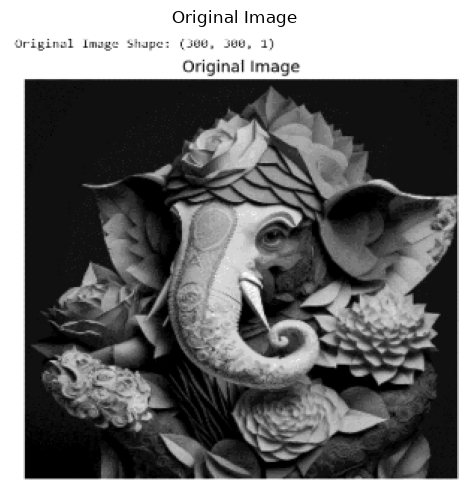

In [5]:
# Load and Preprocess the Image

image_path = "./images/cnn_1.png"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)  
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

In [6]:
# Define Convolution Kernel

kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

After Convolution Shape: (1, 300, 300, 1)


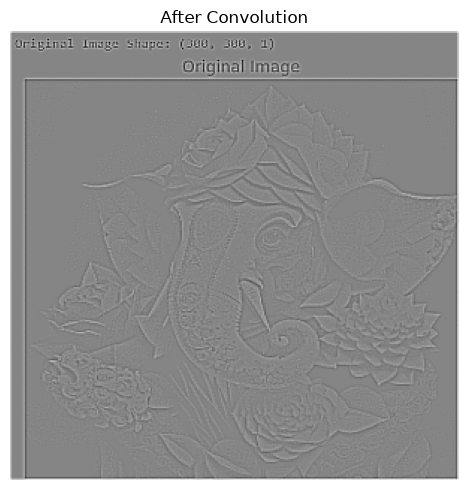

In [7]:
# Apply Convolution Layer

conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()


After ReLU Shape: (1, 300, 300, 1)


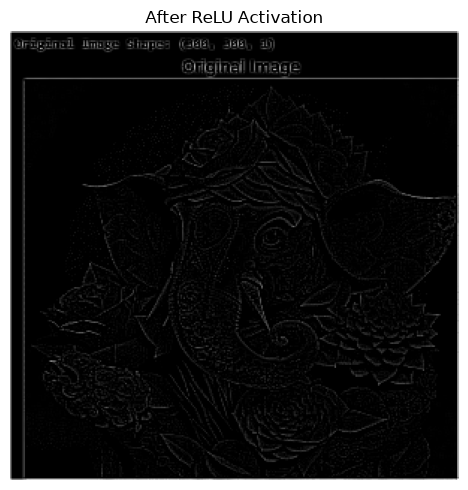

In [8]:
#  Apply ReLU Activation Function

relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()


After Pooling Shape: (1, 150, 150, 1)


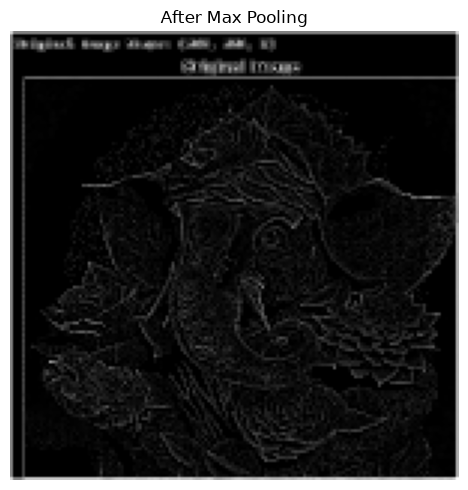

In [9]:
# Apply Max Pooling Layer

pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()


In [10]:
# Apply Flatten Layer

flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[1275.  765.  765.  765.  765.  765.  765.  765.  765.  765.  765.  765.
  765.  765.  765.  765.  765.  765.  765.  765.]


In [11]:
# Add Fully Connected (Dense) Layer

dense_layer = tf.keras.layers.Dense(
    units=64,         
    activation='relu' 
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)


After Fully Connected Layer Shape: (1, 64)
